In [ ]:
# Predictive Modeling (Week 3)

## Hotel Booking Cancellation Prediction

This notebook builds machine learning models to predict booking cancellations using Logistic Regression and Decision Tree.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

sns.set_style("whitegrid")

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
df = pd.read_csv("processed_data.csv")
df.head()

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,customertype,adr,requiredcarparkingspaces,totalofspecialrequests,reservationstatus,reservationstatusdate,arrival_month_number,total_stay,revenue,total_guests
0,0,342,2015,July,27,1,0,0,2,0,...,Transient,0.0,0,0,Check-Out,2015-07-01,7,0,0.0,2
1,0,737,2015,July,27,1,0,0,2,0,...,Transient,0.0,0,0,Check-Out,2015-07-01,7,0,0.0,2
2,0,7,2015,July,27,1,0,1,1,0,...,Transient,75.0,0,0,Check-Out,2015-07-02,7,1,75.0,1
3,0,13,2015,July,27,1,0,1,1,0,...,Transient,75.0,0,0,Check-Out,2015-07-02,7,1,75.0,1
4,0,14,2015,July,27,1,0,2,2,0,...,Transient,98.0,0,1,Check-Out,2015-07-03,7,2,196.0,2


In [5]:
y = df['iscanceled']
X = df.drop(['iscanceled', 'reservationstatus', 'reservationstatusdate'], axis=1)

X = pd.get_dummies(X, drop_first=True)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8349528857479388
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      5248
           1       0.70      0.48      0.57      1544

    accuracy                           0.83      6792
   macro avg       0.78      0.71      0.73      6792
weighted avg       0.82      0.83      0.82      6792



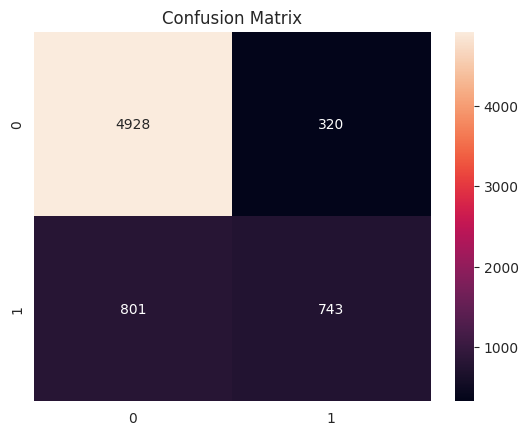

In [9]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

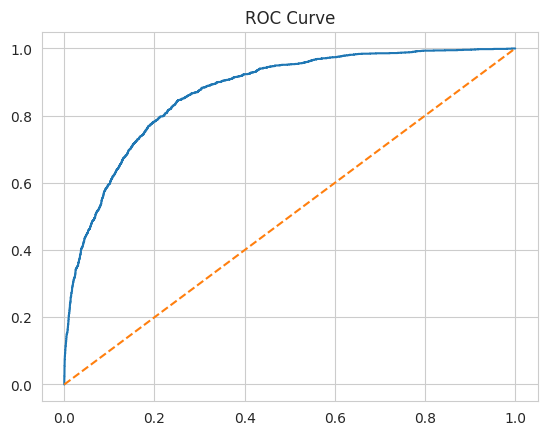

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

In [ ]:
## Feature Importance Analysis

This section identifies the most important factors influencing booking cancellations based on model coefficients.

In [15]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

feature_importance.head(10)

,Feature,Coefficient
10,previouscancellations,1.060795
172,reservedroomtype_E,0.844495
174,reservedroomtype_G,0.761651
171,reservedroomtype_D,0.627063
0,leadtime,0.610261
130,country_PRT,0.607645
173,reservedroomtype_F,0.540626
14,adr,0.517852
1,arrivaldateyear,0.331417
191,customertype_Transient,0.330218


In [16]:
feature_importance.tail(10)

,Feature,Coefficient
16,totalofspecialrequests,-0.483480
11,previousbookingsnotcanceled,-0.486162
185,assignedroomtype_I,-0.492857
162,marketsegment_Direct,-0.495343
164,marketsegment_Offline TA/TO,-0.701947
182,assignedroomtype_F,-0.737258
180,assignedroomtype_D,-0.751169
183,assignedroomtype_G,-0.875472
181,assignedroomtype_E,-0.891624
15,requiredcarparkingspaces,-2.945484
